In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.tsa.stattools import adfuller
from scipy import stats
warnings.filterwarnings('ignore')

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.stats import gaussian_kde


In [2]:
sber = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt')

In [3]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result

In [4]:
sber_5 = good_dataframe(sber, '5 min')
sber_5.head()

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:30:00,SBRF,5 min,2301.0,2346.0,2265.0,2334.0,769
1,2009-01-11 10:35:00,SBRF,5 min,2334.0,2338.0,2320.0,2327.0,399
2,2009-01-11 10:40:00,SBRF,5 min,2322.0,2341.0,2322.0,2340.0,1825
3,2009-01-11 10:45:00,SBRF,5 min,2341.0,2355.0,2340.0,2350.0,2444
4,2009-01-11 10:50:00,SBRF,5 min,2350.0,2376.0,2349.0,2370.0,1614


In [5]:
# Преобразуем датафрейм для удобства работы с 2 свечными паттернами
def shift_features_2_candle(data):
    """Смещает все основные столбцы на 1 период назад

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['time', 'ticker', 'per', 'open', 'high', 'low', 'close', 'volume']

    Returns:
        data (pd.DataFrame): Новый DataFrame с преобразованными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']
    """
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    return data_c

sber_5s = shift_features_2_candle(sber_5)
sber_5s.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,SBRF,5 min,2334.0,2301.0,2327.0,2334.0,2320.0,2265.0,2338.0,2346.0,399,769.0,2009-01-11 10:35:00,2009-01-11 10:30:00
2,SBRF,5 min,2322.0,2334.0,2340.0,2327.0,2322.0,2320.0,2341.0,2338.0,1825,399.0,2009-01-11 10:40:00,2009-01-11 10:35:00
3,SBRF,5 min,2341.0,2322.0,2350.0,2340.0,2340.0,2322.0,2355.0,2341.0,2444,1825.0,2009-01-11 10:45:00,2009-01-11 10:40:00


In [6]:
# Размечаем датафрейм паттерном бычье поглощение
def detection_bullish_engulfing_pattern(data):
    """Функция для детекции бычьего паттерна поглощения

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_engulfing_pattern'
        
    """

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

sber_good = detection_bullish_engulfing_pattern(sber_5s)

In [7]:
# Паттерн бычье харами
def detection_bullish_harami_pattern(data):
    """
    Функция для детекции бычьего паттерна 'харами' (Bullish Harami) на ценовых данныx.
    Паттерн Харами состоит из большой медвежьей свечи, за которой следует маленькая бычья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи.
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_harami_pattern'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_harami_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для бычьего харами
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (close_N_1 < open_N) & 
        (open_N_1 > close_N))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [8]:
# Паттерн просвет в облаках
def detection_break_in_the_clouds(data):
    """
    Свечная модель, состоящая из 2 свечей. Первая свеча падающая, 
    вторая свеча открывается ниже закрытия предыдущей и закрывается по цене, 
    которая превосходит середину предыдущей свечи.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'break_in_the_clouds'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'break_in_the_clouds'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    center = (open_N_1 + close_N_1) / 2
    
    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N < close_N_1) & 
        (close_N < open_N_1) &
        (close_N > center))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [9]:
# Паттерн основание пинцет
def detection_base_of_tweezers(data):
    """
    Свечная модель, состоящая из 2 свечей. Первая свеча падающая, вторая свеча растущая.
    Минимумы равны, 
    которая превосходит середину предыдущей свечи.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'base_of_tweezers'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'base_of_tweezers'
    
    # Векторизованные вычисления
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    min_N_1 = np.minimum(data['close_N-1'], data['low_N-1'])
    min_N = np.minimum(data['open_N'], data['low_N'])
    
    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (min_N == min_N_1))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [10]:
# Паттерн бычья контратака
def detection_bullish_counterattack(data):
    """
    Свечная модель, состоящая из 2 свечей. Первая свеча падающая, вторая свеча растущая.
    Цены закрытия равны или очень близки друг к другу.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_counterattack'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_counterattack'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    

    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        ((np.abs(close_N_1 - close_N) / close_N) * 100 <= 0.05))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [11]:
sber_good.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy
1,SBRF,5 min,2334.0,2301.0,2327.0,2334.0,2320.0,2265.0,2338.0,2346.0,399,769.0,2009-01-11 10:35:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern
2,SBRF,5 min,2322.0,2334.0,2340.0,2327.0,2322.0,2320.0,2341.0,2338.0,1825,399.0,2009-01-11 10:40:00,2009-01-11 10:35:00,1,0,bullish_engulfing_pattern
3,SBRF,5 min,2341.0,2322.0,2350.0,2340.0,2340.0,2322.0,2355.0,2341.0,2444,1825.0,2009-01-11 10:45:00,2009-01-11 10:40:00,0,1,bullish_engulfing_pattern


In [12]:
# Специальная функция для проверки эффективности паттернов 
def filter_min_distance(data, column, N):
    """Некоторые паттерны расположены слишком близко друг к другу, чтобы не было наложения сделок, 
    необходимо удалить все сигналы на покупку, которые появляются во время удержания позиции.
    Время удержания N периодов

    Args:
        data (pd.DataFrame): Преобразованный датафрейм
        'signal' (int64): Сигнальный столбец.
        N (int): Количество периодов, которые мы собираемся удерживать открытую позицию

    Returns:
        data (pd.DataFrame): Исходный датафрейм с отредактированным сигнальным столбцом
    """
    data = data.copy()
    # Получаем все индексы наблюдений где у нас есть сигнал на покупку
    one_index = data[data[column] == 1].index 
    # Получаем разность между этими индексами
    distances = np.diff(one_index)
    # Маска для каждого сигнала. Первый сигнал на покупку всегда True
    mask = [True]
    
    # Перебираем все разности между индексами
    for dist in distances:
        if dist >= N:
            # Если разность между индексами больше N, то все хорошо.
            # Мы добавляем эту сделку в список
            mask.append(True)
        else:
            # Если расстояние меньше, то сделку игнорируем
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data

In [13]:
# Готовим данные для дальнейшей проверки
def data_prepare_for_statistics(data, commission=0.0003):
    """Функция предназначена для обработки результатов стратегий.

    Args:
        data (pd.DataFrame): на вход подается размеченный датафрейм с колонкой 'signal'
        commission (float, optional): Размер комисии в долях процента (0.0003 ~ 0.03%). Defaults to 0.0003.

    Returns:
        list: Возвращаем список с датафреймами, каждый датафрейм это данные по каждой сделке (дата и размер прибыли в %)
    """
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        data_h = data_h.set_index('time_N')
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        exit_candidate = data_h['open_N'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open_N'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        gross_profit = exit_price.values - entry_price.values
        commissions = exit_price.values * commission + entry_price.values * commission
        net_profit = gross_profit - commissions
        percent_profit_net = pd.Series(np.round(net_profit / entry_price.values, 5), index=entry_price.index,
                               name='profit_percent') # % доход за сделку
        percent_profit_without_commission = pd.Series(np.round(gross_profit / entry_price.values, 5), index=entry_price.index,
                               name='gross_profit_percent') # % доход за сделку грязный
        
        strategy_data = pd.DataFrame({'profit_percent_net' : np.array(percent_profit_net), 
                                      'percent_profit_without_commission' : np.array(percent_profit_without_commission),
                                       'N' : N, 
                                       'strategy_name' : data_h['strategy'].iloc[0],
                                       'ticker' : data_h['ticker'].iloc[0],
                                       'period' : data_h['per'].iloc[0]},
                            index=percent_profit_net.index)
        all_strategy.append(strategy_data)
        
    return all_strategy

In [14]:
sber_prepared = data_prepare_for_statistics(sber_good)

In [15]:
# Функция для получения результатов стратегии
def trade_statistics_bull(all_strategy_data):
    """Функция предназначена для агрегирования результатов стратегий по основным финансовым метрикам

    Args:
        all_strategy_data (list): Подаётся список с датафреймами, где для для каждой сделки установлено время и размер прибыли в %.

    Returns:
        data (pd.DataFrame): Возвращаем новый датафрейм со всеми необходимыми метриками для оценки стратегий.
    """
    capital = 100_000
    strategies = []
    for strategy in all_strategy_data:
        
        # Считаем основные метрики
        ticker = strategy['ticker'].iloc[0]
        strategy_name = strategy['strategy_name'].iloc[0]
        period = strategy['period'].iloc[0]
        N = strategy['N'].iloc[0]
        count_of_trades = len(np.array(strategy['profit_percent_net']))
        profit_percent_net = strategy['profit_percent_net']
        percent_profit_without_commission = strategy['percent_profit_without_commission']
        
        # Кривая капитала 
        capital_curve_net = capital * np.cumprod(1 + strategy['profit_percent_net'])
        capital_curve_without_commission = capital * np.cumprod(1 + strategy['percent_profit_without_commission'])
        
        # Профит фактор
        pr_per_net = np.array(strategy['profit_percent_net'])
        profit_factor = np.round(np.sum(pr_per_net[pr_per_net > 0]) / np.abs(np.sum(pr_per_net[pr_per_net < 0])), 3)
        
        # Общий % доход !!!
        total_per_return_r = np.array(np.cumprod(1 + strategy['profit_percent_net']))[-1]
        total_per_return = np.round((total_per_return_r - 1) * 100, 2)
        
        # Win_rate 
        win_rate = np.round(np.mean(pr_per_net > 0), 2)
        
        # R2
        X = np.array(list(range(len(capital_curve_net)))).reshape(-1, 1)
        y = np.array(capital_curve_net)
        lin = LinearRegression()
        lin.fit(X, y)
        y_pred = lin.predict(X)
        beta = np.round(lin.coef_[-1], 2)
        r2 = np.round(metrics.r2_score(y, y_pred), 2)
        
        # Средняя убыточная и прибыльная сделка 
        mean_profit_trade = np.round(np.mean(pr_per_net[pr_per_net > 0]), 3)
        mean_loss_trade = np.round(np.mean(pr_per_net[pr_per_net < 0]), 3)
        avg_profit_loss_ratio = np.round(mean_profit_trade / mean_loss_trade, 3)
        
        # Максимальная просадка
        cumsum_profit = np.cumsum(pr_per_net)
        cummax_profit = np.maximum.accumulate(cumsum_profit)
        max_drawdown = np.max(cummax_profit - cumsum_profit)
        
        strategies.append({
          'ticker' : ticker,
          'strategy name' : strategy_name,
          'period' : period,
          'N' : N,
          'count of trades' : count_of_trades,
          'profit factor' : profit_factor,
          'total percent return' : total_per_return,
          'R2' : r2,
          'beta' : beta,
          'win_rate' : win_rate,
          'mean profit (%)' : mean_profit_trade * 100,
          'mean loss (%)' : mean_loss_trade * 100,
          'profit/loss ratio' : np.round(np.abs(avg_profit_loss_ratio), 2),
          'max drawdown (%)' : np.round(max_drawdown * 100, 1),
          'capital curve net' : capital_curve_net,
          'capital curve without commission' : capital_curve_without_commission,
          'profit percent net' : profit_percent_net,
          'percent profit without commission' : percent_profit_without_commission}
          )
        
    return pd.DataFrame(strategies)

result = trade_statistics_bull(sber_prepared)

In [16]:
# # Проверяем стратегии на множестве ТФ.
# def backtest_strategies_multi_tf(data):
#     """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
#     На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

#     Args:
#         data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

#     Returns:
#         data (pd.DataFrame): Таблица с результатами всех стратегий
#     """
#     data = data.copy()
#     l = []
#     # Перебираем все тф
#     for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
#         data_tm = good_dataframe(data, i)
#         l.append(data_tm)
    
#     all_strategy = []
#     # Для каждого тф проверяем стратегию бычье поглощение
#     for j in l:
#         for func in [detection_bullish_engulfing_pattern, detection_bullish_harami_pattern, 
#                      detection_break_in_the_clouds, detection_base_of_tweezers, detection_bullish_counterattack]:
#             detection_data = func(shift_features_2_candle(j))
#             result = data_prepare_for_statistics(detection_data)
#             final_result = trade_statistics_bull(result)
#             all_strategy.append(final_result)
#     # Объединяем результат   
#     combined_data = pd.concat(all_strategy, ignore_index=True)
    
#     return combined_data

# sber_result_strategies = backtest_strategies_multi_tf(sber)
# sber_result_strategies.head(3)

In [17]:
# Проверяем стратегии на множестве ТФ.
def backtest_strategies_multi_tf():
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    l = []
    # Перебираем все тф
    for a in [r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt']:
        data = pd.read_csv(a)
        for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
            data_tm = good_dataframe(data, i)
            l.append(data_tm)
        
        all_strategy = []
        # Для каждого тф проверяем стратегию бычье поглощение
        for j in l:
            for func in [detection_bullish_engulfing_pattern, detection_bullish_harami_pattern, 
                        detection_break_in_the_clouds, detection_base_of_tweezers, detection_bullish_counterattack]:
                detection_data = func(shift_features_2_candle(j))
                result = data_prepare_for_statistics(detection_data)
                final_result = trade_statistics_bull(result)
                all_strategy.append(final_result)
        # Объединяем результат   
        combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

sber_result_strategies = backtest_strategies_multi_tf()
sber_result_strategies.head(3)

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,beta,win_rate,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission
0,SBRF,bullish_engulfing_pattern,5 min,1,19601,0.349,-100.0,0.45,-2.31,0.25,0.1,-0.1,1.0,1151.9,time_N 2009-01-11 10:45:00 100324.000000 20...,time_N 2009-01-11 10:45:00 100384.000000 20...,time_N 2009-01-11 10:45:00 0.00324 2009-01-...,time_N 2009-01-11 10:45:00 0.00384 2009-01-...
1,SBRF,bullish_engulfing_pattern,5 min,2,19601,0.459,-100.0,0.40,-1.86,0.30,0.2,-0.2,1.0,1194.3,time_N 2009-01-11 10:45:00 101221.000000 20...,time_N 2009-01-11 10:45:00 101282.000000 20...,time_N 2009-01-11 10:45:00 0.01221 2009-01-...,time_N 2009-01-11 10:45:00 0.01282 2009-01-...
2,SBRF,bullish_engulfing_pattern,5 min,3,19023,0.514,-100.0,0.40,-1.83,0.32,0.2,-0.2,1.0,1184.2,time_N 2009-01-11 10:45:00 101008.000000 20...,time_N 2009-01-11 10:45:00 101068.000000 20...,time_N 2009-01-11 10:45:00 0.01008 2009-01-...,time_N 2009-01-11 10:45:00 0.01068 2009-01-...


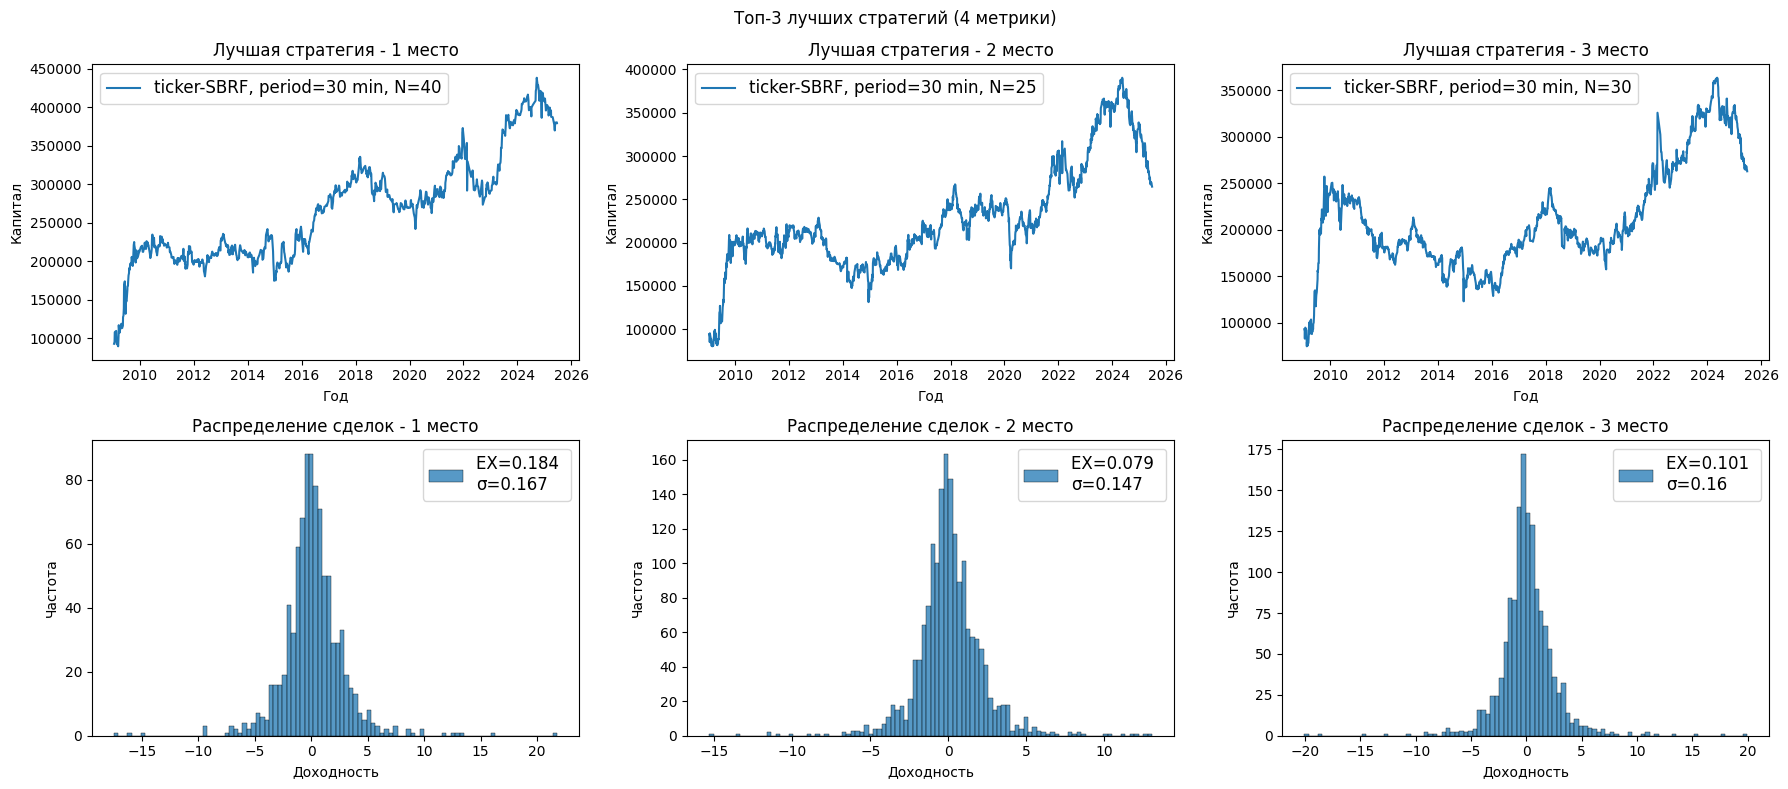

,ticker,strategy name,period,N,count of trades,profit factor,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),total percent return,R2,beta,win_rate
0,SBRF,bullish_harami_pattern,30 min,40,916,1.225,2.0,-1.7,1.18,31.5,279.29,0.81,238.03,0.51
1,SBRF,bullish_harami_pattern,30 min,25,1742,1.116,1.5,-1.3,1.15,50.7,164.69,0.67,99.25,0.49
2,SBRF,bullish_harami_pattern,30 min,30,1414,1.131,1.8,-1.5,1.20,60.4,162.75,0.44,92.65,0.50
3,SBRF,break_in_the_clouds,15 min,45,1733,1.157,1.5,-1.3,1.15,60.3,302.25,0.39,82.75,0.50
4,SBRF,bullish_engulfing_pattern,1h,25,858,1.122,2.2,-1.9,1.16,65.9,85.48,0.40,65.67,0.50
5,SBRF,bullish_harami_pattern,2h,10,865,1.087,1.8,-1.7,1.06,40.6,43.69,0.57,73.40,0.50
6,SBRF,base_of_tweezers,30 min,30,908,1.105,1.8,-1.5,1.20,59.5,59.77,0.14,35.47,0.48
7,SBRF,bullish_harami_pattern,30 min,35,1138,1.143,1.8,-1.6,1.12,71.6,150.10,0.49,113.16,0.50
8,SBRF,base_of_tweezers,15 min,50,1605,1.094,1.6,-1.4,1.14,49.2,93.50,0.41,57.18,0.50
9,SBRF,base_of_tweezers,30 min,35,843,1.104,1.8,-1.7,1.06,53.9,56.65,0.42,65.44,0.52


In [18]:
# Функция для первичного отбора стратегий
def compare_strategies(data):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
    Returns:
        data (pd.DaraFrame): Возвращаем отфильтрованный датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[(data['count of trades'] > 800) & (data['profit factor'] > 1) & (data['total percent return'] > 0) & (data['beta'] > 0)] # Ограничение по количеству сделок
    if data.shape[0] != 0:
        data['profit factor rank'] = data['profit factor'].rank() # Больше лучше
        data['R2 rank'] = data['R2'].rank() # Больше лучше
        data['profit/loss ratio rank'] = data['profit/loss ratio'].rank() # Больше лучше
        data['max drawdown rank'] = data['max drawdown (%)'].rank(ascending=False) # Меньше лучше
        data['best model'] = data['profit factor rank'] + data['R2 rank'] + data['profit/loss ratio rank'] + data['max drawdown rank']
        
        # Построение графиков 3 лучших стратегий
        
        data.sort_values('best model', ascending=False, inplace=True, ignore_index=True)
        if data.shape[0] >= 3:    
            # График
            fig, axes = plt.subplots(2, 3, figsize=(18, 8))
            plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
            
            # Первые 3 графика
            sns.lineplot(data.loc[0, 'capital curve net'], ax=axes[0, 0], label=f'ticker-{data.loc[0, 'ticker']}, period={data.loc[0, 'period']}, N={data.loc[0, 'N']}');
            sns.lineplot(data.loc[1, 'capital curve net'], ax=axes[0, 1], label=f'ticker-{data.loc[1, 'ticker']}, period={data.loc[1, 'period']}, N={data.loc[1, 'N']}');
            sns.lineplot(data.loc[2, 'capital curve net'], ax=axes[0, 2], label=f'ticker-{data.loc[2, 'ticker']}, period={data.loc[2, 'period']}, N={data.loc[2, 'N']}');
            axes[0, 0].legend(fontsize=12)
            axes[0, 1].legend(fontsize=12)
            axes[0, 2].legend(fontsize=12)
            
            axes[0, 0].set_title('Лучшая стратегия - 1 место')
            axes[0, 1].set_title('Лучшая стратегия - 2 место')
            axes[0, 2].set_title('Лучшая стратегия - 3 место')
            axes[0, 0].set_ylabel('Капитал')
            axes[0, 1].set_ylabel('Капитал')
            axes[0, 2].set_ylabel('Капитал')
            axes[0, 0].set_xlabel('Год')
            axes[0, 1].set_xlabel('Год')
            axes[0, 2].set_xlabel('Год')
            
            # Вторые 3 графика
            sns.histplot(data.loc[0, 'profit percent net'] * 100, ax=axes[1, 0], bins=100, 
                            label=f'EX={np.round(np.mean(data.loc[0, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit percent net"])),3)}');
            sns.histplot(data.loc[1, 'profit percent net'] * 100, ax=axes[1, 1], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[1, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit percent net"])),3)}');
            sns.histplot(data.loc[2, 'profit percent net'] * 100, ax=axes[1, 2], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[2, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit percent net"])),3)}');
            axes[1, 0].legend(fontsize=12)
            axes[1, 1].legend(fontsize=12)
            axes[1, 2].legend(fontsize=12)
                
            axes[1, 0].set_title('Распределение сделок - 1 место')
            axes[1, 1].set_title('Распределение сделок - 2 место')
            axes[1, 2].set_title('Распределение сделок - 3 место')
            axes[1, 0].set_ylabel('Частота')
            axes[1, 1].set_ylabel('Частота')
            axes[1, 2].set_ylabel('Частота')
            axes[1, 0].set_xlabel('Доходность')
            axes[1, 1].set_xlabel('Доходность')
            axes[1, 2].set_xlabel('Доходность')
                
            plt.tight_layout()
            plt.show()
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'beta', 'win_rate']]
            display(data_new.head(10))       
            return data
        else:
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'beta', 'win_rate']]
            display(data_new.head(10))
            return data  
            
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')
    
res = compare_strategies(sber_result_strategies)

ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК
ПАТТЕРН СЛУЧАЕН


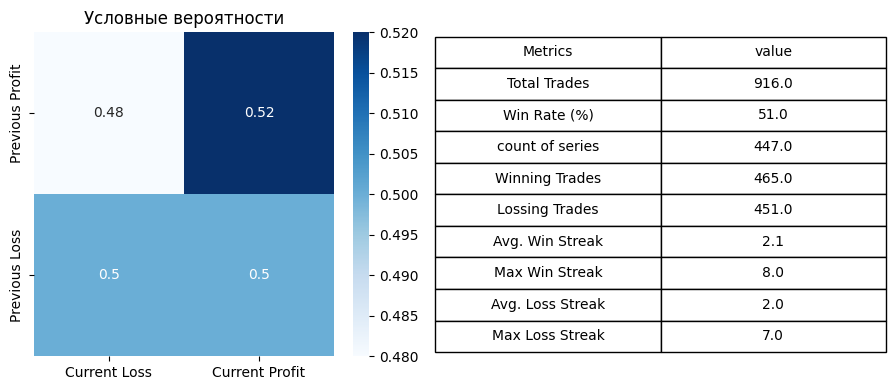

In [19]:
def run_analysis(lst):
    """Функция предназначена на статистического анализа торговой стратегии. Метрики, которые расчитываем:
    - Количество сделок всего, количество прибыльных/убыточных сделок
    - Количество серий (сколько раз был переход от прибыли к убытку и наоборот)
    - Средняя серия прибыльных/убыточных сделок
    - Максимальная серия прибыльных/убыточных сделок
    - Тест Вальда-Вольфовица для определения случайности в сериях сделок
    - Условные вероятности : P(W | W), P(W | L), P(L | W), P(L | L)

    Args:
        lst (list): Список чистых доходностей в %.

    Returns:
        Теловая карта с условными вероятностями и таблицу со всеми метриками.
    """
    if len(lst) > 0:
        lst_new = np.array(lst)
        lst_sign = (lst_new > 0).astype(int)
        n_win = np.sum(lst_sign) # Количество прибыльных сделок
        n_loss = len(lst_sign) - n_win # Количество убыточных сделок
        win_rate = np.round(n_win / len(lst_sign) * 100)
        
        # Считаем количество серий
        count_series = 1
        for i in range(1, len(lst_sign)):
            if lst_sign[i-1] != lst_sign[i]:
                count_series += 1
                
        # Считаем максимальное количество подряд идущих прибыльных сделок и среднюю серию прибыльных сделок
        list_win = []
        count_win = 0
        for i in range(len(lst_sign)):
            if lst_sign[i] == 1:
                count_win += 1
            else:
                if count_win != 0:
                    list_win.append(count_win)
                count_win = 0
        if count_win > 0:
            list_win.append(count_win) 
        
        mean_wins_series = np.round(np.mean(list_win), 1)
        max_wins_series = np.max(list_win)     
        
        # Считаем максимальное количество подряд идущих убыточных сделок и среднюю серию убыточных сделок
        list_loss = []
        count_loss = 0
        for i in range(1, len(lst_sign)):
            if lst_sign[i] == 0:
                count_loss += 1
            else:
                if count_loss != 0:
                    list_loss.append(count_loss)
                count_loss = 0
        if count_loss > 0:
            list_loss.append(count_loss)
        
        mean_loss_series = np.round(np.mean(list_loss), 1)
        max_loss_series = np.max(list_loss)
        
        
        # Проводим тест Вальда-Вольфовица для определения случайности в сериях сделок
        print('=' * 70)
        print('ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК')
        print('=' * 70)
        z_stat, p_value = runstest_1samp(lst_sign, correction=False)
        if p_value < 0.05:
            print('ПАТТЕРН НЕСЛУЧАЕН')
            if z_stat < 0:
                print('Наблюдается кластеризация, серии длиннее случайных.')
            else:
                print('Частое чередование (серии короче случайных).')
        else:
            print('ПАТТЕРН СЛУЧАЕН')
            
        # Условные вероятности
        df_usl = pd.DataFrame({'current' : lst_sign})
        df_usl['previous'] = df_usl['current'].shift(1)
        df_usl.dropna(inplace=True)
        Crosstable = np.round(pd.crosstab(columns=df_usl['current'], index=df_usl['previous'], normalize='index'), 2)
        Crosstable.index = ['Previous Loss', 'Previous Profit']
        Crosstable.columns = ['Current Loss', 'Current Profit']
        
        # Таблица с метриками
        final_data = pd.Series({'Total Trades' : len(lst_sign),
                                'Win Rate (%)' : win_rate,
                                'count of series' : count_series,
                                'Winning Trades' : n_win,
                                'Lossing Trades' : n_loss,
                                'Avg. Win Streak' : mean_wins_series,
                                'Max Win Streak' : max_wins_series,
                                'Avg. Loss Streak' : mean_loss_series,
                                'Max Loss Streak' : max_loss_series}).reset_index().rename(columns={'index' : 'Metrics', 0 : 'value'})
        
        # Вывод
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
        sns.heatmap(Crosstable, annot=True, cmap="Blues", ax=ax1)
        ax1.invert_yaxis()
        ax1.set_title('Условные вероятности')
        
        
        table = ax2.table(
            cellText=final_data.values,
            colLabels=final_data.columns,
            cellLoc='center',
            loc='center')
        ax2.axis('off')
        table.scale(1.2, 1.8)
        table.auto_set_font_size(False)
        plt.tight_layout()
        plt.show()


        
        return final_data
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')


ac = run_analysis(res.loc[0, 'profit percent net'])

ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)
Ряд стационарен

ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)
Лаг 1: Наличие автокорреляции - Нет (p > 0.05)
Лаг 2: Наличие автокорреляции - Нет (p > 0.05)
Лаг 3: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 4: Наличие автокорреляции - Нет (p > 0.05)
Лаг 5: Наличие автокорреляции - Да (p ≤ 0.05)

ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)
Уровень доверия: 5.0%: Распределение Не нормальное
Уровень доверия: 2.5%: Распределение Не нормальное
Уровень доверия: 1.0%: Распределение Не нормальное

СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ
МЕДИАНА: 0.053%
НЕТ оснований утверждать, что медиана значимо отличается от 0

БУСТРЕП (95%)
Средняя:   0.18%    [0.0%, 0.36%]. Вероятность убыточности: 2.3%
Медиана:   0.05%  [-0.07%, 0.2%]. Вероятность убыточности: 31.6%



,Normal,Without outliers
winrate (%),51.0,51.0
mean return (%),0.18,0.15
median return (%),0.05,0.05
profit factor,1.23,1.27
Normal dist?,NO,NO
p-value (= 0?),0.059,0.031
= 0?,YES,NO


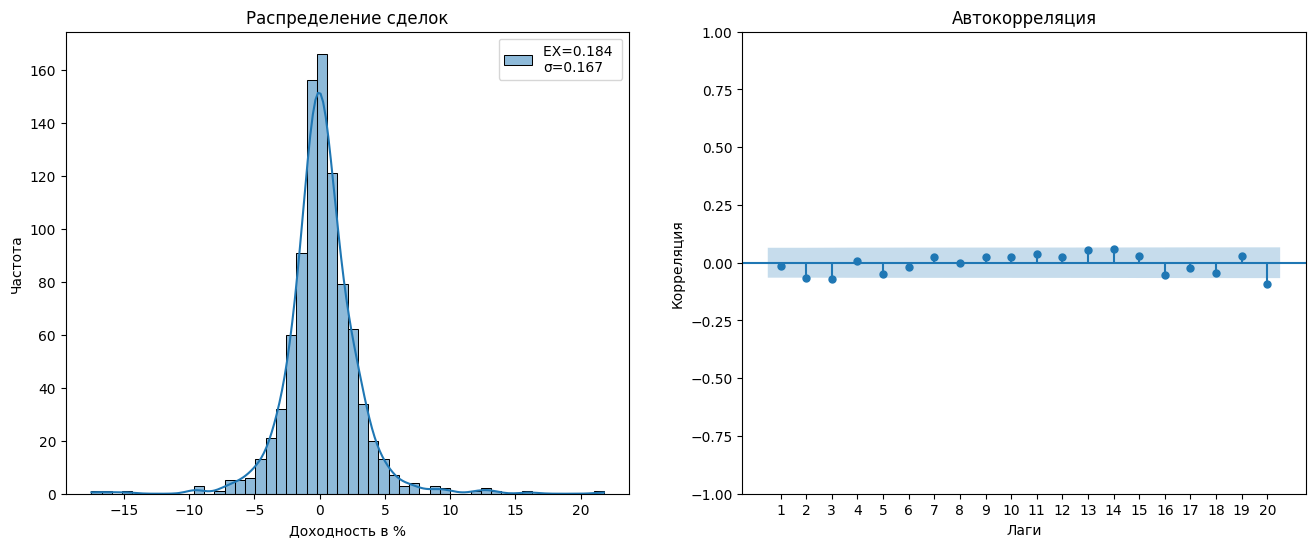

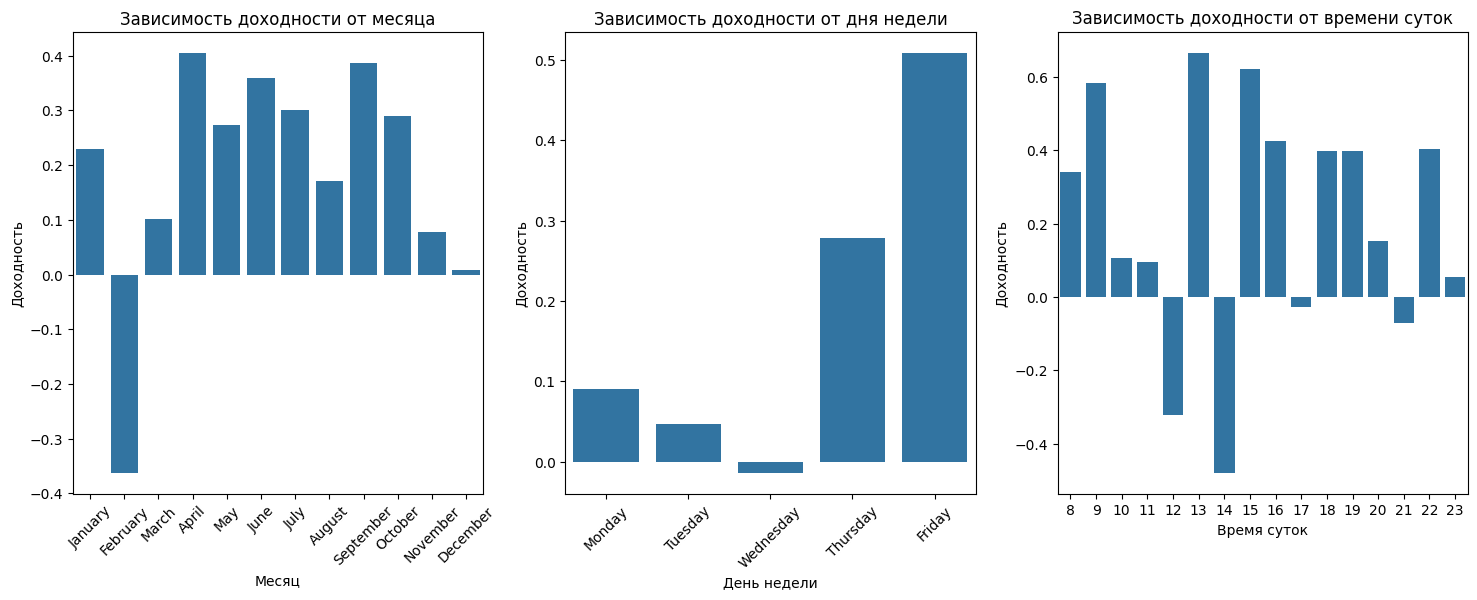

In [20]:
# Функция для глубокого статистического анализа паттернов
def deep_statistics(data, indx):
    """
    Функция предназначена для глубокого статистического анализа торговых стратегий.
    Алгоритм расчитывает:
    - График распределения доходностей и автокорреляцию
    - Проверку на стационарность
    - Проверку на автокорреляцию
    - Проверку на Нормальность
    - Сравнение средней доходности с 0
    - Анализ временных факторов на доходность

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
        indx (int): индекс стратегии
        
    """
    
    pr_percent_net = data.loc[indx, 'profit percent net']
    # 1. График
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.histplot(pr_percent_net * 100, ax=axes[0], bins=50, kde=True, 
                 label=f'EX={np.round(np.mean(pr_percent_net) * 100, 3)} \nσ={np.round(np.sqrt(np.std(pr_percent_net)),3)}')
    axes[0].set_title('Распределение сделок')
    axes[0].set_xlabel('Доходность в %')
    axes[0].set_ylabel('Частота')
    axes[0].legend(fontsize=10)
    plot_acf(pr_percent_net, zero=False, ax=axes[1], lags=20)
    axes[1].set_title('Автокорреляция')
    axes[1].set_xlabel('Лаги')
    axes[1].set_ylabel('Корреляция')
    axes[1].set_xticks(range(1, 21))
    
    # 2. Стационарность
    print('=' * 61)
    print('ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)')
    print('=' * 61)
    result_adfuler = adfuller(pr_percent_net)
    if result_adfuler[1] < 0.05:
        print('Ряд стационарен')
    else:
        print('Ряд нестационарен')
    print()
    
    
    # 3. Тест Льюнг-Бокса
    print('=' * 61)
    print('ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)')
    print('=' * 61)
    lb_test = acorr_ljungbox(pr_percent_net, lags=np.arange(1, 6))
    for i in range(1, 6):
        print(f"Лаг {i}: Наличие автокорреляции - {'Да (p ≤ 0.05)' if lb_test.loc[i, 'lb_pvalue'] <= 0.05 else 'Нет (p > 0.05)'}")
    print()

    # 4. Нормальность распределения
    print('=' * 61)
    print('ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)')
    print('=' * 61)
    Anderson_test = stats.anderson(pr_percent_net, dist='norm')
    for i in range(2, len(Anderson_test.significance_level)):
        sl, cv = Anderson_test.significance_level[i], Anderson_test.critical_values[i]
        print(f'Уровень доверия: {sl}%: {"Нормальное распределение" if Anderson_test.statistic < cv else "Распределение Не нормальное"}')
    print()

    # 5. Сравнение с нулевой доходностью.
    print('=' * 61)
    print('СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ')
    print('=' * 61)
    if Anderson_test.statistic < Anderson_test.critical_values[2]:
        distr = 'YES'
        print(f'СРЕДНЯЯ: {np.round(np.mean(pr_percent_net) * 100, 3)}%')
        _, p_value = stats.ttest_1samp(pr_percent_net, popmean=0)
        if p_value < 0.05:
            zero = 'NO'
            print('Средняя значимо отличается от 0')
        else:
            zero = 'YES'
            print('НЕТ оснований утверждать, что средняя значимо отличается от 0')
    else:
        distr = 'NO'
        print(f'МЕДИАНА: {np.round(np.median(pr_percent_net) * 100, 3)}%')
        _, p_value = stats.wilcoxon(pr_percent_net)
        if p_value < 0.05:
            zero = 'NO'
            print('Медиана значимо отличается от 0')
        else:
            zero = 'YES'
            print('НЕТ оснований утверждать, что медиана значимо отличается от 0')
    print()
    
    # 6. Бутстреп
    print('=' * 61)
    print('БУСТРЕП (95%)')
    print('=' * 61)
    n_trades = len(pr_percent_net)
    list_mean = []
    list_median = []
    for i in range(10_000):
        sample = np.random.choice(pr_percent_net, size=n_trades, replace=True)
        median_sample = np.median(sample)
        mean_sample = np.mean(sample)
        list_median.append(median_sample)
        list_mean.append(mean_sample)
        
    mean_bootstrap = np.round(np.mean(list_mean) * 100, 2) 
    mean_lower = np.round(np.percentile(list_mean, q=2.5) * 100, 2)
    mean_upper = np.round(np.percentile(list_mean, q=97.5) * 100, 2)
    prob_mean = np.round(np.mean(np.array(list_mean) < 0) * 100, 1)
    
    median_bootstrap = np.round(np.median(list_median) * 100, 2)
    median_lower = np.round(np.percentile(list_median, q=2.5) * 100, 2)
    median_upper = np.round(np.percentile(list_median, q=97.5) * 100, 2)
    prob_median = np.round(np.mean(np.array(list_median) < 0) * 100, 1)
    print(f'Средняя:   {mean_bootstrap}%    [{mean_lower}%, {mean_upper}%]. Вероятность убыточности: {prob_mean}%')
    print(f'Медиана:   {median_bootstrap}%  [{median_lower}%, {median_upper}%]. Вероятность убыточности: {prob_median}%')
    
    # 7. Удаление 5% самых больших убытков и 5% самых больших прибылей
    five_upper = np.quantile(pr_percent_net, 0.95)
    five_lower = np.quantile(pr_percent_net, 0.05)
    pr_percent_net_blowout = pr_percent_net[(five_lower < pr_percent_net) & (pr_percent_net < five_upper)]
    # Win rate
    win_rate_n = np.round(np.mean(pr_percent_net > 0) * 100)
    win_rate_blowout = np.round(np.mean(pr_percent_net_blowout > 0) * 100)
    
    # Средние и медианы
    mean_profit_n = np.round(np.mean(pr_percent_net) * 100, 2)
    mean_profit_blowout = np.round(np.mean(pr_percent_net_blowout) * 100, 2)
    median_profit_n = np.round(np.median(pr_percent_net) * 100, 2)
    median_profit_blowout = np.round(np.median(pr_percent_net_blowout) * 100, 2)
    
    # Профит фактор
    profit_factor_n = np.round(np.sum(pr_percent_net[pr_percent_net > 0]) / np.abs(np.sum(pr_percent_net[pr_percent_net < 0])), 2)
    profit_factor_blowout = np.round(np.sum(pr_percent_net_blowout[pr_percent_net_blowout > 0]) / np.abs(np.sum(pr_percent_net_blowout[pr_percent_net_blowout < 0])), 2)
    
    # Сравнение с нулевой доходностью
    Anderson_test_blowout = stats.anderson(pr_percent_net_blowout, dist='norm')
    if Anderson_test_blowout.statistic < Anderson_test_blowout.critical_values[2]:
        distr_blowout = 'YES'
        _, p_value_b = stats.ttest_1samp(pr_percent_net_blowout, popmean=0)
        if p_value_b < 0.05:
            zero_b = 'NO'
        else:
            zero_b = 'YES'
    else:
        distr_blowout = 'NO'
        _, p_value_b = stats.wilcoxon(pr_percent_net_blowout)
        if p_value_b < 0.05:
            zero_b = 'NO'
        else:
            zero_b = 'YES'
    print()
    
    # Собираем всё вместе в табличку
    dict_normal = {'winrate (%)' : win_rate_n, 'mean return (%)' : mean_profit_n, 'median return (%)' : median_profit_n, 
                   'profit factor' : profit_factor_n,
                   'Normal dist?' : distr, 'p-value (= 0?)' : np.round(p_value, 3), '= 0?' : zero}
    dict_blowout = {'winrate (%)' : win_rate_blowout, 'mean return (%)' : mean_profit_blowout, 'median return (%)' : median_profit_blowout, 
                    'profit factor' : profit_factor_blowout,
                   'Normal dist?' : distr_blowout, 'p-value (= 0?)' : np.round(p_value_b, 3), '= 0?' : zero_b}
    df = pd.DataFrame({'Normal' : dict_normal, 'Without outliers' : dict_blowout})
    display(df)
    

    # 6 Временной анализ
    data_percent = (pr_percent_net * 100).to_frame().reset_index()
    data_percent['time_N'] = pd.to_datetime(data_percent['time_N'])
    data_percent['Month'] = data_percent['time_N'].dt.month_name()
    data_percent['day_of_week'] = data_percent['time_N'].dt.day_name()
    data_percent['hour'] = data_percent['time_N'].dt.hour
    
    # Группировка
    months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']
    weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    data_percent_group_month = data_percent.groupby('Month')['profit_percent_net'].mean().reset_index()
    data_percent_group_day_of_week = data_percent.groupby('day_of_week')['profit_percent_net'].mean().reset_index()
    data_percent_group_hour = data_percent.groupby('hour')['profit_percent_net'].mean().reset_index()
    
    # График 
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1
    sns.barplot(data_percent_group_month, x=data_percent_group_month['Month'], y=data_percent_group_month['profit_percent_net'], ax=axes[0],
                order=months)
                
    axes[0].set_title('Зависимость доходности от месяца')
    axes[0].set_xlabel('Месяц')
    axes[0].set_ylabel('Доходность')
    axes[0].set_xticklabels(labels=months, rotation=45)
    
    # 2
    sns.barplot(data_percent_group_day_of_week, x=data_percent_group_day_of_week['day_of_week'], y=data_percent_group_day_of_week['profit_percent_net'], ax=axes[1],
                order=weekdays)
    axes[1].set_title('Зависимость доходности от дня недели')
    axes[1].set_xlabel('День недели')
    axes[1].set_ylabel('Доходность')
    axes[1].set_xticklabels(labels=weekdays, rotation=45)
    
    # 3
    sns.barplot(data_percent_group_hour, x=data_percent_group_hour['hour'], y=data_percent_group_hour['profit_percent_net'], ax=axes[2])
    axes[2].set_title('Зависимость доходности от времени суток')
    axes[2].set_xlabel('Время суток')
    axes[2].set_ylabel('Доходность')

    
result_statistics = deep_statistics(res, 0)

## 2. Подготовка к моделированию 

In [21]:
res.head(2)

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,beta,win_rate,...,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission,profit factor rank,R2 rank,profit/loss ratio rank,max drawdown rank,best model
0,SBRF,bullish_harami_pattern,30 min,40,916,1.225,279.29,0.81,238.03,0.51,...,31.5,time_N 2009-01-13 22:30:00 93117.000000 20...,time_N 2009-01-13 22:30:00 93175.000000 20...,time_N 2009-01-13 22:30:00 -0.06883 2009-01-...,time_N 2009-01-13 22:30:00 -0.06825 2009-01-...,25.0,25.0,22.5,25.0,97.5
1,SBRF,bullish_harami_pattern,30 min,25,1742,1.116,164.69,0.67,99.25,0.49,...,50.7,time_N 2009-01-13 22:30:00 94149.000000 20...,time_N 2009-01-13 22:30:00 94207.000000 20...,time_N 2009-01-13 22:30:00 -0.05851 2009-01-...,time_N 2009-01-13 22:30:00 -0.05793 2009-01-...,18.0,24.0,18.0,18.0,78.0


In [22]:
sber = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt')

In [23]:
def preperation_to_modeling(data, period, func, N, profit):
    """_summary_

    Args:
        data (_type_): _description_
        period (_type_): _description_
        func (_type_): _description_
        N (_type_): _description_
        profit (_type_): _description_

    Returns:
        _type_: _description_
    """
    data_timeframe = good_dataframe(data, period)
    data_with_pattern = func(shift_features_2_candle(data_timeframe))
    
    # Обрезка
    data_with_pattern.loc[len(data_with_pattern) - 51 : len(data_with_pattern), ['pattern', 'signal']] = 0
    data_filter = filter_min_distance(data_with_pattern, 'signal', N)
    data_filter['signal_N-1'] = data_filter['signal'].shift(-1)
    data_filter.loc[data_filter['signal_N-1'] == 0, 'pattern'] = 0
    data_filter.drop(['signal', 'signal_N-1', 'per', 'ticker', 'strategy'], axis=1, inplace=True)
    data_filter.dropna(inplace=True)
    
    # Соединяем доходности
    result = profit.loc[0, 'profit percent net']
    data_filter = data_filter.set_index('time_N')
    final_data = data_filter.join(result).fillna(0)
    final_data = final_data.reset_index()
    final_data['profit_percent_net'] = final_data['profit_percent_net'].shift(-1)
    return final_data

df = preperation_to_modeling(sber, '30 min', detection_bullish_harami_pattern, 40, res)


In [24]:
df.head()

,time_N,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N-1,pattern,profit_percent_net
0,2009-01-11 11:00:00,2366.0,2301.0,2347.0,2361.0,2324.0,2265.0,2369.0,2380.0,4471,7797.0,2009-01-11 10:30:00,0,0.0
1,2009-01-11 11:30:00,2343.0,2366.0,2346.0,2347.0,2338.0,2324.0,2355.0,2369.0,1198,4471.0,2009-01-11 11:00:00,0,0.0
2,2009-01-11 12:00:00,2346.0,2343.0,2339.0,2346.0,2339.0,2338.0,2354.0,2355.0,1420,1198.0,2009-01-11 11:30:00,0,0.0
3,2009-01-11 12:30:00,2340.0,2346.0,2339.0,2339.0,2328.0,2339.0,2344.0,2354.0,844,1420.0,2009-01-11 12:00:00,0,0.0
4,2009-01-11 13:00:00,2335.0,2340.0,2341.0,2339.0,2330.0,2328.0,2346.0,2344.0,734,844.0,2009-01-11 12:30:00,0,0.0


## 3. Создание признаков

In [25]:
# Признаки по дате и времени
def data_time_features(data):
    """_summary_

    Args:
        data (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = data.copy()
    data['time_N'] = pd.to_datetime(data['time_N'])
    data['months_N'] = data['time_N'].dt.month
    data['days_N'] = data['time_N'].dt.day
    data['hours_N'] = data['time_N'].dt.hour
    data.drop('time_N', axis=1, inplace=True)
    
    return data

In [26]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    """_summary_

    Args:
        data (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = data.copy()
    
    # Отношение тела свечи ко всей свече
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    # есть ли тело и есть ли свеча
    data['has_body_N'] = (body_N > 0).astype('int')
    data['has_body_N-1'] = (body_N_1 > 0).astype('int')
    data['has_full_candle_N'] = (full_candle_N > 0).astype('int')
    data['has_full_candle_N-1'] = (full_candle_N_1 > 0).astype('int')
    
    data['ratio_body_to_all_candle_N'] = np.where(full_candle_N > 0, body_N / full_candle_N, np.nan)
    data['ratio_body_to_all_candle_N-1'] = np.where(full_candle_N_1 > 0, body_N_1 / full_candle_N_1, np.nan)
    
    # Отношение верхней тени к телу свечи
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    data['ratio_up_shadow_to_body_N'] = np.where(body_N > 0, up_shadow_N / body_N, np.nan)
    data['ratio_up_shadow_to_body_N-1'] = np.where(body_N_1 > 0, up_shadow_N_1 / body_N_1, np.nan)

    # Отношение нижней тени к телу свечи
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    data['ratio_low_shadow_to_body_N'] = np.where(body_N > 0, low_shadow_N / body_N, np.nan)
    data['ratio_low_shadow_to_body_N-1'] = np.where(body_N_1 > 0, low_shadow_N_1 / body_N_1, np.nan)

    # Отношение верхней тени к нижней тени
    data['ratio_up_to_low_shadow_N'] = np.where((low_shadow_N > 0) & (up_shadow_N > 0), up_shadow_N / low_shadow_N, np.nan)
    data['ratio_up_to_low_shadow_N-1'] = np.where((low_shadow_N_1 > 0) & (up_shadow_N_1 > 0), up_shadow_N_1 / low_shadow_N_1, np.nan)

    # Добавляем бинарный признак: есть ли обе тени
    data['has_both_shadows_N'] = ((low_shadow_N > 0) & (up_shadow_N > 0)).astype('int')
    data['has_both_shadows_N-1'] = ((low_shadow_N_1 > 0) & (up_shadow_N_1 > 0)).astype('int')
    
    data = data.fillna(0)

    
    return data

In [27]:
def data_one_candle_features_2(data):
    """_summary_

    Args:
        data (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = data.copy()
    
    def ATR(data, period=14):
        high_low = data['high_N'] - data['low_N']
        high_close_prev = np.abs(data['high_N'] - data['close_N'].shift(1))
        low_close_prev = np.abs(data['low_N'] - data['close_N'].shift(1))
    
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        ATR = TR.rolling(period).mean()
    
        return ATR
    
    atr = ATR(data).shift(1)
    valid_mask = ~atr.isna()
    data = data[valid_mask]
    atr = atr[valid_mask]
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    atr_safe = np.where(atr != 0, atr, 10e-8 )
    
    # Тело свечи / ATR
    data['body_ATR_N'] = body_N / atr_safe
    data['body_ATR_N-1'] = body_N_1 / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR_N'] = full_candle_N / atr_safe
    data['full_candle_ATR_N-1'] = full_candle_N_1 / atr_safe
    
    # Верхняя тень / ATR
    data['up_shadow_ATR_N'] = up_shadow_N / atr_safe
    data['up_shadow_ATR_N-1'] = up_shadow_N_1 / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR_N'] = low_shadow_N / atr_safe
    data['low_shadow_ATR_N-1'] = low_shadow_N_1 / atr_safe
    
    return data

In [28]:
def data_two_candles_features(data):
    """_summary_

    Args:
        data (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = data.copy()
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    
    data['ratio_body_N_to_N-1'] = np.where(body_N_1 > 0, body_N / body_N_1, np.nan)
    data['ratio_full_candle_N_to_N-1'] = np.where(full_candle_N_1 > 0, full_candle_N / full_candle_N_1, np.nan)
    data['ratio_up_shadow_N_to_N-1'] = np.where(up_shadow_N_1 > 0, up_shadow_N / up_shadow_N_1, np.nan)
    data['ratio_low_shadow_N_to_N-1'] = np.where(low_shadow_N_1 > 0, low_shadow_N / low_shadow_N_1, np.nan)
    
    # Бинарные признаки
    data['has_up_shadow_N'] = (up_shadow_N > 0).astype('int')
    data['has_low_shadow_N'] = (low_shadow_N > 0).astype('int')
    data['has_up_shadow_N-1'] = (up_shadow_N_1 > 0).astype('int')
    data['has_low_shadow_N-1'] = (low_shadow_N_1 > 0).astype('int')
    
    data = data.fillna(0)
    return data
     

In [29]:
def indicators(data):
    """_summary_

    Args:
        data (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI_N'] = rsi(data['close_N'], 14)
    data['RSI_N-1'] = data['RSI_N'].shift(1)
    
    # SMA
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200]
    for i in sma_periods:
        # Для N: используем данные до N-1
        sma_N = data['close_N'].shift(1).rolling(i).mean()
        # Для N-1: данные доступны
        sma_N_1 = data['close_N-1'].rolling(i).mean()
        
        data[f'diff_SMA_{i}_N'] = ((data['close_N'] - sma_N) / (sma_N + 1e-8)) * 100
        data[f'diff_SMA_{i}_N-1'] = ((data['close_N-1'] - sma_N_1) / (sma_N_1 + 1e-8)) * 100
    
    # Volume
    def volume(data, column):
        data = data.copy()
        # Для текущего значения volume_N используем данные до N-1
        shifted = data[column].shift(1)
        volume_ma = shifted.rolling(63).mean()
        volume_std = shifted.rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / (volume_std + 1e-8)
        return data
    
    data = volume(data, 'volume_N')
    data = volume(data, 'volume_N-1')
    
    # Стохастик
    def stochastic_oscillator(high, low, close, k_period=14, d_period=3):
        low_min = low.rolling(window=k_period).min()
        high_max = high.rolling(window=k_period).max()
        k = 100 * (close - low_min) / (high_max - low_min + 1e-8)
        d = k.rolling(window=d_period).mean()
        return k, d
    
    stoch_k_N, stoch_d_N = stochastic_oscillator(
        data['high_N'].shift(1),
        data['low_N'].shift(1),
        data['close_N'].shift(1))
    
    data['STOCH_K_N'] = stoch_k_N
    data['STOCH_D_N'] = stoch_d_N
    
    stoch_k_N1, stoch_d_N1 = stochastic_oscillator(
        data['high_N-1'],
        data['low_N-1'],
        data['close_N-1'])
    
    data['STOCH_K_N-1'] = stoch_k_N1
    data['STOCH_D_N-1'] = stoch_d_N1
    return data

In [30]:
def create_lag_indicators(data):
    """_summary_

    Args:
        data (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    close_base = data['close_N-1']
    daily_change = close_base.pct_change()
    
    for i in periods:
        # Изменения
        data[f'Change_{i}_N-1'] = (close_base / close_base.shift(i) - 1) * 100
        
        # up/down дни
        up_rolling = (daily_change > 0).rolling(i).sum()
        down_rolling = (daily_change < 0).rolling(i).sum()
        
        data[f'up_days_{i}_N-1'] = up_rolling
        data[f'down_days_{i}_N-1'] = down_rolling
        data[f'up_down_ratio_{i}_N-1'] = np.where(down_rolling > 0, up_rolling / down_rolling, 0)
    
    for i in periods:
        for suffix in ['Change', 'up_days', 'down_days', 'up_down_ratio']:
            col = f'{suffix}_{i}_N-1'
            if col in data.columns:
                data[f'{suffix}_{i}_N'] = data[col].shift(1)
    return data

In [31]:
def add_features(data):
    """_summary_

    Args:
        data (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = data.copy()
    # Добавляем признаки
    data = data_time_features(data)
    data = data_one_candle_features_1(data)
    data = data_one_candle_features_2(data)
    data = data_two_candles_features(data)
    data = indicators(data)
    data = create_lag_indicators(data)
    
    # Финальная подготовка
    data = data[data['pattern'] == 1]
    data.drop(['open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N', 'low_N-1',
       'high_N', 'high_N-1', 'time_N-1', 'volume_N', 'volume_N-1', 'pattern'], axis=1, inplace=True)
    data['profit_percent_net'] = data['profit_percent_net'] * 100
    data.dropna(inplace=True)
    return data
    

In [32]:
df = add_features(df)
df.head(3)

,profit_percent_net,months_N,days_N,hours_N,has_body_N,has_body_N-1,has_full_candle_N,has_full_candle_N-1,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,...,down_days_10_N,up_down_ratio_10_N,Change_15_N,up_days_15_N,down_days_15_N,up_down_ratio_15_N,Change_20_N,up_days_20_N,down_days_20_N,up_down_ratio_20_N
277,13.247,1,23,14,1,1,1,1,0.096774,0.139535,...,7.0,0.428571,-2.922078,7.0,8.0,0.875000,-7.085146,9.0,11.0,0.818182
639,1.429,2,11,20,1,1,1,1,0.500000,0.538462,...,4.0,1.500000,4.793757,9.0,6.0,1.500000,10.070258,13.0,7.0,1.857143
730,-14.782,2,17,11,1,1,1,1,0.208333,0.242424,...,7.0,0.428571,-5.237045,6.0,9.0,0.666667,-6.270447,8.0,11.0,0.727273


## 4. Сравнение признаков

In [33]:
def clean_features(data, threshold = 0.95):
    
    data = data.copy()
    n_col = data.shape[1]
    print(f'Признаков до удаления: {n_col}')
    
    # Удаляем константные признаки
    target_column = 'profit_percent_net'
    delete_list = [col for col in data.columns if data[col].nunique() == 1]
    data.drop(delete_list, axis=1, inplace=True)
    features_list = [col for col in data.columns if col != target_column]
    print(f'Константные признаки:', delete_list)

    # Занимаемся мультиколлинеарностью
    del_set = set()
    for i, col1 in enumerate(features_list):
        for j in range(i+1, len(features_list)):
            col2 = features_list[j]
            corr_between = np.abs(data[col1].corr(data[col2]))
            corr1 = np.abs(data[target_column].corr(data[col1]))
            corr2 = np.abs(data[target_column].corr(data[col2]))
            if corr_between >= threshold:
                
                if corr1 >= corr2:
                    del_set.add(col2)
                else:
                    del_set.add(col1)
    data.drop(list(del_set), axis=1, inplace=True)
    print(f'Признаки с мультиколлинеарностью > {threshold}:', *list(del_set))
    print(f'Признаков после удаления: {n_col - len(del_set) - len(delete_list)}')       
    return data    
            
df_ml =  clean_features(df)
df_ml

Признаков до удаления: 106
Константные признаки: ['has_body_N', 'has_body_N-1', 'has_full_candle_N', 'has_full_candle_N-1', 'up_down_ratio_1_N-1', 'up_down_ratio_1_N']
Признаки с мультиколлинеарностью > 0.95: diff_SMA_200_N-1 diff_SMA_100_N down_days_3_N-1 diff_SMA_10_N STOCH_K_N-1 diff_SMA_150_N-1 down_days_20_N diff_SMA_200_N down_days_1_N diff_SMA_20_N diff_SMA_150_N up_days_20_N-1 diff_SMA_30_N up_days_10_N-1 up_days_3_N up_days_20_N diff_SMA_50_N up_days_15_N down_days_15_N-1 down_days_10_N down_days_1_N-1 up_days_5_N-1 STOCH_D_N-1 diff_SMA_20_N-1 up_days_5_N RSI_N down_days_15_N up_down_ratio_20_N
Признаков после удаления: 72


,profit_percent_net,months_N,days_N,hours_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,...,up_down_ratio_3_N,Change_5_N,down_days_5_N,up_down_ratio_5_N,Change_10_N,up_days_10_N,up_down_ratio_10_N,Change_15_N,up_down_ratio_15_N,Change_20_N
277,13.247,1,23,14,0.096774,0.139535,5.000000,2.500000,4.333333,3.666667,...,2.0,-4.533844,3.0,0.666667,-5.974843,3.0,0.428571,-2.922078,0.875000,-7.085146
639,1.429,2,11,20,0.500000,0.538462,0.888889,0.428571,0.111111,0.428571,...,2.0,-0.476443,1.0,4.000000,0.159830,6.0,1.500000,4.793757,1.500000,10.070258
730,-14.782,2,17,11,0.208333,0.242424,2.600000,0.750000,1.200000,2.375000,...,0.0,-3.751400,4.0,0.250000,-3.643498,3.0,0.428571,-5.237045,0.666667,-6.270447
777,-1.025,2,18,21,0.058824,0.307692,2.000000,1.625000,14.000000,0.625000,...,0.0,-0.204778,3.0,0.666667,2.885292,5.0,1.000000,4.577969,0.875000,-6.700702
873,0.836,2,25,15,0.166667,0.526316,1.000000,0.100000,4.000000,0.800000,...,0.5,-1.288136,3.0,0.666667,-1.952862,3.0,0.428571,0.831025,1.142857,2.247191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116060,-0.057,5,30,15,0.013699,0.254717,23.000000,2.481481,49.000000,0.444444,...,0.0,1.080401,0.0,0.000000,0.648683,7.0,2.333333,0.817036,2.000000,0.972938
116147,-0.082,6,4,13,0.107143,0.342105,6.500000,1.153846,1.833333,0.769231,...,2.0,0.384808,2.0,1.500000,1.377524,8.0,4.000000,0.988260,2.000000,1.102814
116322,0.164,6,13,11,0.026087,0.329545,16.666667,1.517241,20.666667,0.517241,...,0.0,-0.535697,5.0,0.000000,-0.383227,3.0,0.428571,-0.599089,0.666667,-0.725629
116407,0.067,6,17,23,0.300000,0.750000,0.600000,0.166667,1.733333,0.166667,...,0.5,-0.142807,2.0,1.500000,-0.073041,6.0,1.500000,0.076331,1.500000,0.022251


Попробывать vif (реализовать самому)

## 5. Моделируем

In [34]:
def target_variable(data, variant=1):
    """_summary_

    Args:
        data (_type_): _description_
        variant (int, optional): _description_. Defaults to 1.

    Returns:
        _type_: _description_
    """
    data = data.copy()
    # 1 Вариант (Бинарная классификация): Если доходность больше 0, то 1, иначе 0
    if variant == 1:
        data['target'] = np.where(data['profit_percent_net'] > 0, 1, 0)
    # 2 Вариант (Мультиклассовая классификация)
    elif variant == 2:
        data['target'] = np.where(data['profit_percent_net'] > 1, 1,
                                  np.where(data['profit_percent_net'] < -1, 0, -1))
    # 3 Вариант (Регрессия)
    elif variant == 3:
        data['target'] = data['profit_percent_net']
        
    data.drop('profit_percent_net', axis=1, inplace=True)
    return data
df_final = target_variable(df_ml)

In [35]:
df_final['target'].value_counts()

target
1    464
0    450
Name: count, dtype: int64

### 1. Логистическая регрессия

In [36]:
from sklearn.linear_model import LogisticRegression
X, y = df_final.drop('target', axis=1), np.array(df_final['target'])

Train: 731, Test: 183
                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.49      0.53      0.51        92
           1       0.48      0.43      0.45        91

    accuracy                           0.48       183
   macro avg       0.48      0.48      0.48       183
weighted avg       0.48      0.48      0.48       183

         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
C=0.1: Accuracy=0.47, Precision=0.47, Recall=0.45, F1=0.46
C=1: Accuracy=0.48, Precision=0.48, Recall=0.43, F1=0.45
C=10: Accuracy=0.46, Precision=0.45, Recall=0.42, F1=0.43


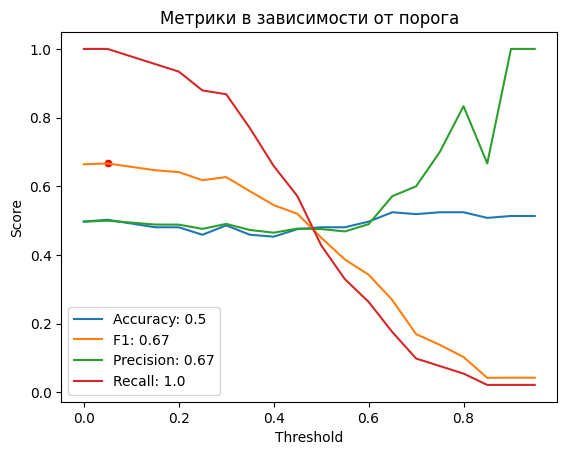

Лучший порог: 0.05


In [67]:
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
def LogisticRegression_function(X, y):
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    # Попробуем подобрать гиперпараметры
    print('=' * 57)
    print('         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    for c in [0.1, 1, 10]:
        model = LogisticRegression(C=c, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
    
        print(f"C={c}: Accuracy={np.round(acc, 2)}, Precision={np.round(prec, 2)}, Recall={np.round(rec, 2)}, F1={np.round(f1, 2)}")
    
    # График вероятностей
    l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0, 1, 0.05)
    
    for threshold in thresholds:
        y_pred = (y_pred_prob > threshold).astype('int')
        
        # расчитывыаем метрики
        acc_score = metrics.accuracy_score(y_test, y_pred)
        F1_score = metrics.f1_score(y_test, y_pred)
        prec_score = metrics.precision_score(y_test, y_pred)
        recall_scores = metrics.recall_score(y_test, y_pred)
        
        # Добавляем в списки
        l_accuracy.append(acc_score)
        l_f1.append(F1_score)
        l_prec.append(prec_score)
        l_recall.append(recall_scores)
    
    best_index = np.argmax(l_f1)
    best_threshold = thresholds[best_index]
    best_f1 = l_f1[best_index]
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_f1[best_index], 2)}')
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
    sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Метрики в зависимости от порога')
    plt.show()
    print(f'Лучший порог: {np.round(best_threshold, 2)}')
result_log_reg = LogisticRegression_function(X, y)   
        
 

Train: 731, Test: 183
                    ДЕРЕВЬЯ РЕШЕНИЙ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.48      0.40      0.44        92
           1       0.48      0.56      0.52        91

    accuracy                           0.48       183
   macro avg       0.48      0.48      0.48       183
weighted avg       0.48      0.48      0.48       183

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 14.
Метрики: Accuracy - 0.48, F1 - 0.51, Precision - 0.48, Recall - 0.54
               РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ
              precision    recall  f1-score   support

           0       0.54      0.47      0.50        92
           1       0.53      0.60      0.56        91

    accuracy                           0.54       183
   macro avg       0.54      0.54      0.53       183
weighted avg       0.54      0.54      0.53       183



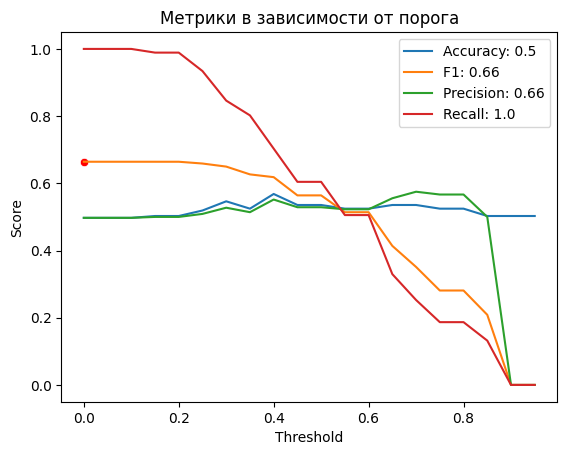

Лучший порог: 0.0


In [69]:
def DecisionTreeClassifier_function(X, y):
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = DecisionTreeClassifier(max_depth=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    ДЕРЕВЬЯ РЕШЕНИЙ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 15):
        model = DecisionTreeClassifier(max_depth=5, random_state=42)
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f={'n_feature' : n_feature, 'Accuracy' : np.round(acc, 2), 
                'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
        res_feature.append(dict_f)
    
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_feature}.')
    print(f'Метрики: Accuracy - {df.loc[0, 'Accuracy']}, F1 - {df.loc[0, 'F1']}, Precision - {df.loc[0, 'Precision']}, Recall - {df.loc[0, 'Recall']}')
    
    # Получаем признаки лучшей модели
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    res = []
    for deep in [4, 5, 6]:
        for leaf in [20, 30]:
            for splits in [30, 40]:
                model = DecisionTreeClassifier(max_depth=deep, min_samples_leaf=leaf, min_samples_split=splits, random_state=42)
                model.fit(X_train_new, y_train)
                y_pred = model.predict(X_test_new)
            
                acc = metrics.accuracy_score(y_test, y_pred)
                prec = metrics.precision_score(y_test, y_pred, zero_division=0)
                rec = metrics.recall_score(y_test, y_pred, zero_division=0)
                f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
            
                dict={'max_depth' : deep, 'min_samples_leaf' : leaf, 'min_samples_split' : splits, 
                      'Accuracy' : np.round(acc, 2), 'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
                res.append(dict)
    df_1 = pd.DataFrame(res).sort_values('F1', ascending=False, ignore_index=True)
    
    # Обучаем финальную лучшую модель
    print('=' * 57)
    print(f'               РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ')
    print('=' * 57)
    max_depth, min_samples_leaf, min_samples_split	= df_1.loc[0, 'max_depth'], df_1.loc[0, 'min_samples_leaf'], df_1.loc[0, 'min_samples_split']
    final_model = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split, random_state=42)
    final_model.fit(X_train_new, y_train)
    y_pred_final = final_model.predict(X_test_new)
    y_pred_proba_final = final_model.predict_proba(X_test_new)[:, 1]
    print(metrics.classification_report(y_test, y_pred_final))
    plt.show()
    
    # График вероятностей
    l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
    thresholds = np.arange(0, 1, 0.05)
    
    for threshold in thresholds:
        y_pred = (y_pred_proba_final > threshold).astype('int')
        
        # расчитывыаем метрики
        acc_score = metrics.accuracy_score(y_test, y_pred)
        F1_score = metrics.f1_score(y_test, y_pred)
        prec_score = metrics.precision_score(y_test, y_pred)
        recall_scores = metrics.recall_score(y_test, y_pred)
        
        # Добавляем в списки
        l_accuracy.append(acc_score)
        l_f1.append(F1_score)
        l_prec.append(prec_score)
        l_recall.append(recall_scores)
    
    best_index = np.argmax(l_f1)
    best_threshold = thresholds[best_index]
    best_f1 = l_f1[best_index]
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_f1[best_index], 2)}')
    sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
    sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Метрики в зависимости от порога')
    plt.show()
    print(f'Лучший порог: {np.round(best_threshold, 2)}')
result_dec_tree = DecisionTreeClassifier_function(X, y) 



In [47]:
from sklearn.ensemble import RandomForestClassifier
def RandomForestClassifier_function(X, y):
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = RandomForestClassifier(max_depth=5, n_estimators=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    СЛУЧАЙНЫЙ ЛЕС')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 36):
        model = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42, n_jobs=-1)
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f={'n_feature' : n_feature, 'Accuracy' : np.round(acc, 2), 
                'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
        res_feature.append(dict_f)
        
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_feature}.')
    print(f'Метрики: Accuracy - {df.loc[0, 'Accuracy']}, F1 - {df.loc[0, 'F1']}, Precision - {df.loc[0, 'Precision']}, Recall - {df.loc[0, 'Recall']}')
    
    # Получаем признаки лучшей модели
    model = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42, n_jobs=-1)
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    res = []
    for n_estimators in [50, 100, 150]:
        for max_depth in [4, 5, 6]:
            for leaf in [20, 30]:
                model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=leaf, random_state=42, n_jobs=-1)
                model.fit(X_train_new, y_train)
                y_pred = model.predict(X_test_new)
            
                acc = metrics.accuracy_score(y_test, y_pred)
                prec = metrics.precision_score(y_test, y_pred, zero_division=0)
                rec = metrics.recall_score(y_test, y_pred, zero_division=0)
                f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
            
                dict={'n_estimators' : n_estimators, 'min_samples_leaf' : leaf, 'max_depth' : max_depth, 
                      'Accuracy' : np.round(acc, 2), 'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
                res.append(dict)
    df_1 = pd.DataFrame(res).sort_values('F1', ascending=False, ignore_index=True)
    
    # Обучаем финальную лучшую модель
    print('=' * 57)
    print(f'               РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ')
    print('=' * 57)
    max_depth, n_estimators, min_samples_leaf = df_1.loc[0, 'max_depth'], df_1.loc[0, 'n_estimators'], df_1.loc[0, 'min_samples_leaf']
    final_model = RandomForestClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, n_estimators=n_estimators, random_state=42)
    final_model.fit(X_train_new, y_train)
    y_pred_final = final_model.predict(X_test_new)
    print(metrics.classification_report(y_test, y_pred_final))
result_random_forest = RandomForestClassifier_function(X, y) 



Train: 731, Test: 183
                    СЛУЧАЙНЫЙ ЛЕС
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.47      0.41      0.44        92
           1       0.47      0.53      0.50        91

    accuracy                           0.47       183
   macro avg       0.47      0.47      0.47       183
weighted avg       0.47      0.47      0.47       183

ОТБОР ПРИЗНАКОВ:


KeyboardInterrupt: 

In [ ]:
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

def LGBMClassifier_function(X, y):
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = LGBMClassifier(max_depth=5, n_estimators=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    lightGMB')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 36):
        model = LGBMClassifier(max_depth=5, n_estimators=100, random_state=42, n_jobs=-1)
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f={'n_feature' : n_feature, 'Accuracy' : np.round(acc, 2), 
                'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
        res_feature.append(dict_f)
        
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_feature}.')
    print(f'Метрики: Accuracy - {df.loc[0, 'Accuracy']}, F1 - {df.loc[0, 'F1']}, Precision - {df.loc[0, 'Precision']}, Recall - {df.loc[0, 'Recall']}')
    
    # Получаем признаки лучшей модели
    model = LGBMClassifier(max_depth=5, n_estimators=100, random_state=42, n_jobs=-1)
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    res = []
    for min_child_samples in [20, 30, 40]:
        for max_depth in [4, 5, 6]:
            for leaf in [8, 16, 24]:
                model = LGBMClassifier(n_estimators=100, max_depth=max_depth, num_leaves=leaf, min_child_samples=min_child_samples, random_state=42, n_jobs=-1)
                model.fit(X_train_new, y_train)
                y_pred = model.predict(X_test_new)
            
                acc = metrics.accuracy_score(y_test, y_pred)
                prec = metrics.precision_score(y_test, y_pred, zero_division=0)
                rec = metrics.recall_score(y_test, y_pred, zero_division=0)
                f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
            
                dict={'min_samples_leaf' : leaf, 'max_depth' : max_depth, 'min_child_samples' : min_child_samples,
                      'Accuracy' : np.round(acc, 2), 'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
                res.append(dict)
    df_1 = pd.DataFrame(res).sort_values('F1', ascending=False, ignore_index=True)
    
    # Обучаем финальную лучшую модель
    print('=' * 57)
    print(f'               РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ')
    print('=' * 57)
    max_depth, min_child_samples, min_samples_leaf = df_1.loc[0, 'max_depth'], df_1.loc[0, 'min_child_samples'], df_1.loc[0, 'min_samples_leaf']
    final_model = LGBMClassifier(max_depth=max_depth, min_child_samples=min_child_samples, min_samples_leaf=min_samples_leaf, n_estimators=100, random_state=42)
    final_model.fit(X_train_new, y_train)
    y_pred_final = final_model.predict(X_test_new)
    print(metrics.classification_report(y_test, y_pred_final))
result_random_forest = LGBMClassifier_function(X, y) 

Train: 731, Test: 183
                    lightGMB
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.47      0.43      0.45        92
           1       0.47      0.51      0.49        91

    accuracy                           0.47       183
   macro avg       0.47      0.47      0.47       183
weighted avg       0.47      0.47      0.47       183

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 15.
Метрики: Accuracy - 0.55, F1 - 0.55, Precision - 0.55, Recall - 0.56
               РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ
              precision    recall  f1-score   support

           0       0.54      0.52      0.53        92
           1       0.53      0.55      0.54        91

    accuracy                           0.54       183
   macro avg       0.54      0.54      0.54       183
weighted avg       0.54      0.54      0.54       183

